# Credit Risk

Dataset source: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

# STEP 1: LOAD THE CREDIT RISK DATASET

In [71]:

# Import pandas
import pandas as pd

# Read the CSV file
df = pd.read_csv("data_credit_risk.csv")
# df = pd.read_csv("https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_credit_risk.csv")


# Display the first 5 rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## About Dataset
Detailed data description of Credit Risk dataset:
```
Feature Name	Description
person_age	Age
person_income	Annual Income
person_home_ownership	Home ownership
person_emp_length	Employment length (in years)
loan_intent	Loan intent
loan_grade	Loan grade
loan_amnt	Loan amount
loan_int_rate	Interest rate
loan_status	Loan status (0 is non default 1 is default)
loan_percent_income	Percent income
cb_person_default_on_file	Historical default
cb_preson_cred_hist_length	Credit history length

# EDA

In [72]:
# Check the shape of the dataset

print("Shape of dataset:", df.shape)

Shape of dataset: (32581, 12)


In [73]:
# Display column names

print(df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [75]:
# Summary statistics for numerical columns

df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [76]:
# Summary for categorical columns

df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


--- Value Counts for person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64




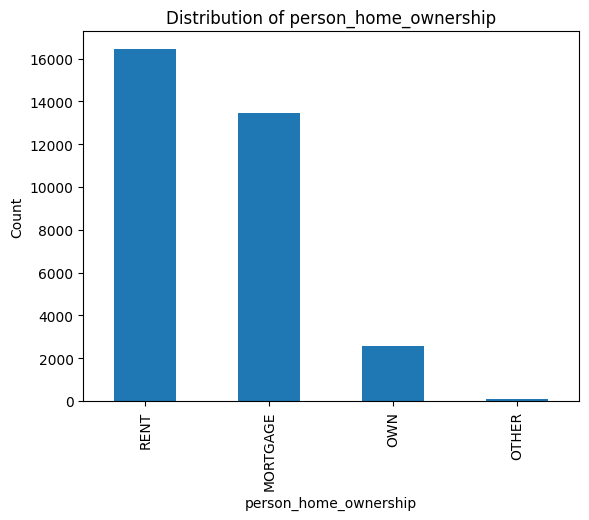

---------------------------------


--- Value Counts for loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64




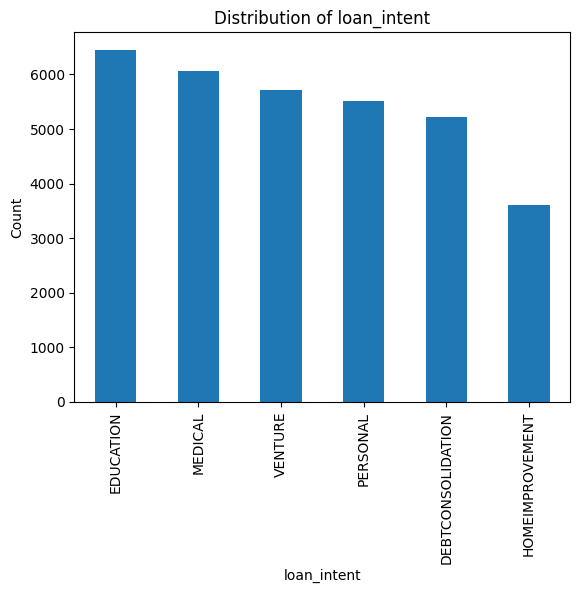

---------------------------------


--- Value Counts for loan_grade ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64




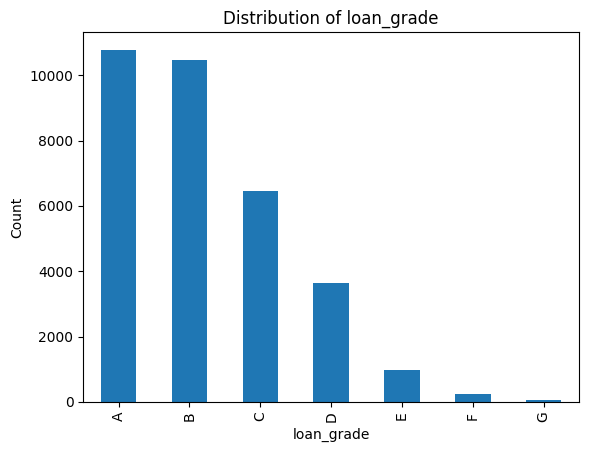

---------------------------------


--- Value Counts for cb_person_default_on_file ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64




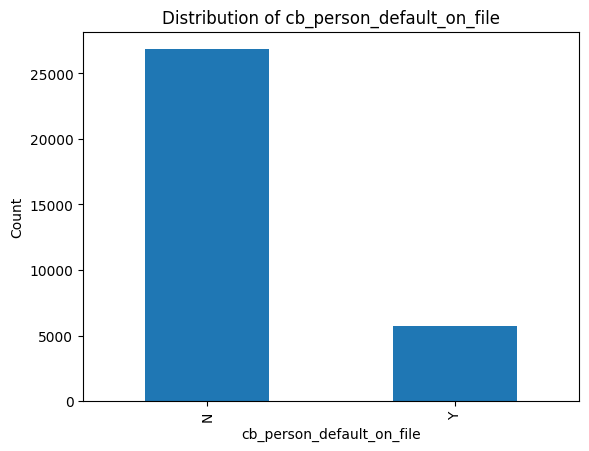

---------------------------------




In [77]:
import matplotlib.pyplot as plt

# Loop through columns with 'object' data type
for col in df.select_dtypes(include=['object']).columns:
    print(f"--- Value Counts for {col} ---")
    counts = df[col].value_counts()
    print(counts)
    print("\n")
    
    # Plot the value counts as a bar chart
    counts.plot(kind='bar', title=f'Distribution of {col}', ylabel='Count')
    plt.show()  # Ensures each plot displays separately in your notebook/script
    print("---------------------------------\n\n")


## Duplicates

In [78]:
# 1) Count the total number of duplicate rows
df.duplicated().sum()

165

In [79]:
#2) 
# Identify all copies (keep=False ensures the original and its duplicates are included)
duplicate_mask = df.duplicated(keep=False)

# Filter the dataframe
duplicates_df = df[duplicate_mask]

# Sort by specific columns (or all columns) so identical rows sit next to each other
# Replace 'column1', 'column2' with your actual column names
sorted_duplicates = duplicates_df.sort_values(by=['person_age','person_income'])

# Display the result
print(sorted_duplicates)

       person_age  person_income person_home_ownership  person_emp_length  \
15944          21           8088                  RENT                NaN   
16835          21           8088                  RENT                NaN   
2431           21          15600                  RENT                0.0   
17758          21          15600                  RENT                0.0   
2498           21          18000                  RENT                0.0   
...           ...            ...                   ...                ...   
32010          42          39996              MORTGAGE                2.0   
29484          43          11340                  RENT                4.0   
32279          43          11340                  RENT                4.0   
31676          49         120000              MORTGAGE               12.0   
32172          49         120000              MORTGAGE               12.0   

             loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status 

In [80]:
# 3)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [81]:
# 4) Count the total number of duplicate rows
df.duplicated().sum()

0

## missing values

In [82]:
# Check for missing values

print("missing value:\n", df.isnull().sum())

missing value:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


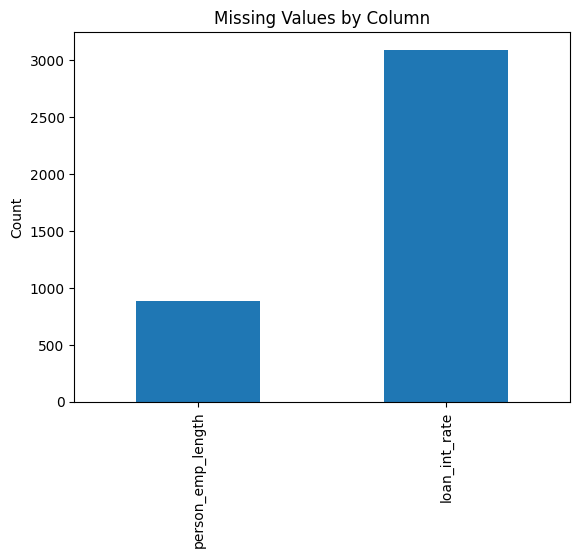

In [83]:
# VISUAL: MISSING VALUES

missing = df.isnull().sum()
missing = missing[missing > 0]

missing.plot(kind='bar')

plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.show()

In [84]:
# Check percentage of missing values

missing_percent = df.isnull().mean() * 100
print(missing_percent)

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.736303
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.547754
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


<Axes: ylabel='Density'>

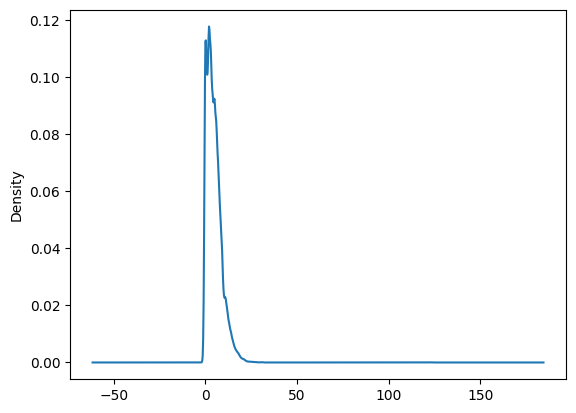

In [85]:
# Plot the KDE of a column - person_emp_length
df['person_emp_length'].plot(kind='kde')

# It is not normal distribution, so use median for missing value

<Axes: ylabel='Density'>

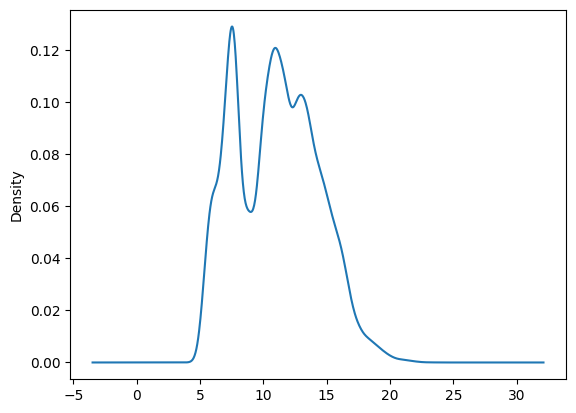

In [86]:
df['loan_int_rate'].plot(kind='kde')

# It is not normal distribution, so use median for missing value

In [87]:
# Fill missing values with median:

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Verify that missing values are gone
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


# View target variable distribution: Imbalanced

In [88]:
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [89]:
print("percentage:\n", df['loan_status'].value_counts(normalize=True)*100)

percentage:
 loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


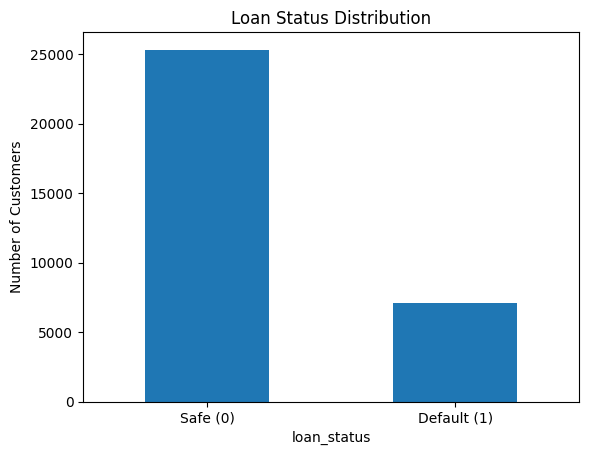

In [90]:
# VISUAL 1: TARGET VARIABLE DISTRIBUTION

import matplotlib.pyplot as plt

df['loan_status'].value_counts().sort_index().plot(
    kind='bar'
)

plt.xticks([0, 1], ['Safe (0)', 'Default (1)'], rotation=0)
plt.title('Loan Status Distribution')
plt.ylabel('Number of Customers')
plt.show()

# VISUAL: DEFAULT RATE BY LOAN GRADE

loan_grade
A    0.099598
B    0.163185
C    0.207518
D    0.590608
E    0.644860
F    0.705394
G    0.984375
Name: loan_status, dtype: float64





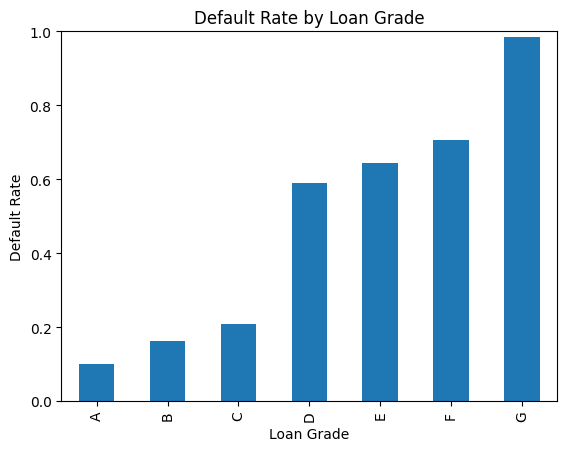

In [91]:
default_by_grade = df.groupby('loan_grade')['loan_status'].mean()
print(default_by_grade)
print("\n\n")

default_by_grade.plot(kind='bar')

plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.xlabel('Loan Grade')
plt.ylim(0, 1)
plt.show()

# VISUAL: INCOME DISTRIBUTION BY CLASS

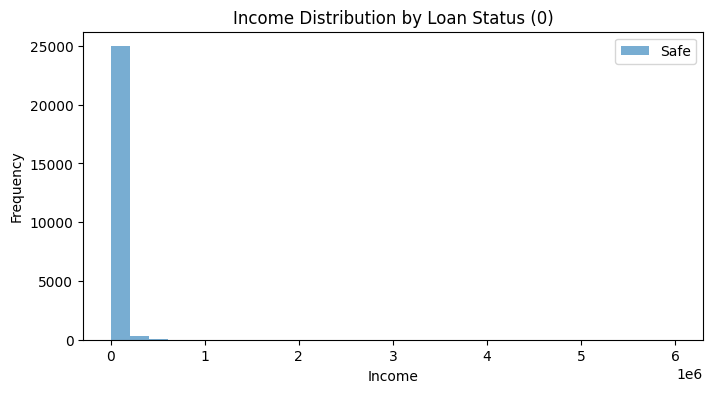

In [92]:
plt.figure(figsize=(8, 4))

plt.hist(
    df[df['loan_status'] == 0]['person_income'],
    bins=30,
    alpha=0.6,
    label='Safe'
)

plt.legend()
plt.title('Income Distribution by Loan Status (0)')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

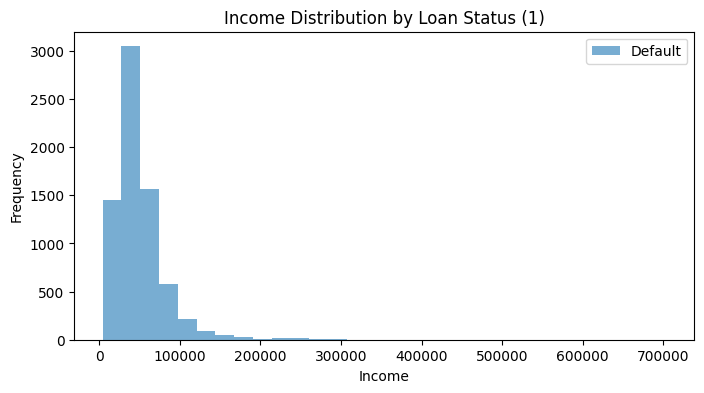

In [93]:
plt.figure(figsize=(8, 4))

plt.hist(
    df[df['loan_status'] == 1]['person_income'],
    bins=30,
    alpha=0.6,
    label='Default'
)

plt.legend()
plt.title('Income Distribution by Loan Status (1)')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

# Outliers

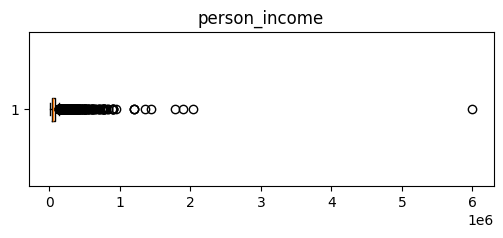

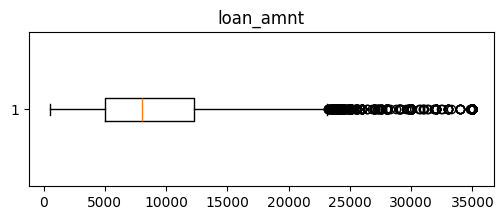

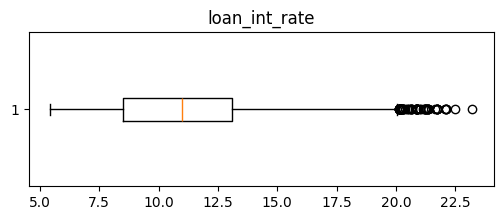

In [94]:
column_outliers = ['person_income', 'loan_amnt', 'loan_int_rate'] 

for col in column_outliers:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [95]:
column_outliers = ['person_income', 'loan_amnt', 'loan_int_rate']

for col in column_outliers:
    # 1. Calculate quartiles and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Define upper and lower bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Filter and print the outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"--- Outliers in {col} (Total: {len(outliers)}) ---")
    print(outliers.values)
    print("\n")


--- Outliers in person_income (Total: 1478) ---
[500000 162500 306000 ... 780000 160000 150000]


--- Outliers in loan_amnt (Total: 1679) ---
[35000 35000 35000 ... 25000 24000 35000]


--- Outliers in loan_int_rate (Total: 70) ---
[20.25 20.16 21.21 20.11 21.27 21.74 20.3  21.36 21.36 22.11 20.89 21.74
 20.62 20.2  20.3  20.89 20.62 20.89 20.89 20.11 20.48 20.25 20.89 20.62
 22.11 21.14 20.16 20.99 21.21 21.74 20.89 21.74 20.25 21.64 20.17 20.11
 20.11 22.06 20.3  21.36 20.17 20.86 20.52 20.16 20.16 20.9  20.89 20.17
 21.21 21.36 21.27 21.21 20.86 20.25 20.11 20.86 22.11 21.27 21.74 20.3
 22.48 21.36 20.16 20.11 23.22 20.4  20.99 20.69 20.53 20.62]




In [96]:
# Clip them
for col in column_outliers:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(lower_bound, upper_bound)

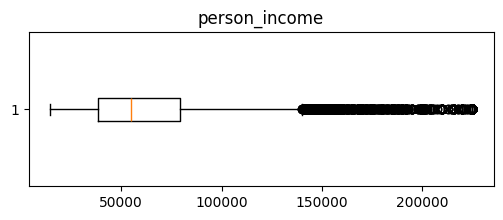

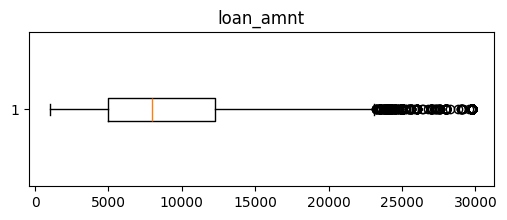

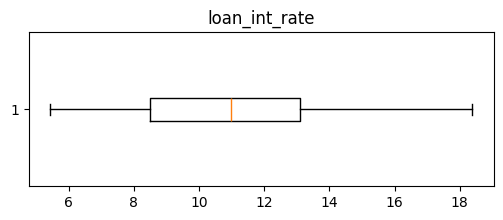

In [97]:
for col in column_outliers:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

# STEP 2: DEFINE FEATURES (X) AND TARGET (y)


In [98]:
# Target variable
y = df['loan_status']

# Input features (all columns except target)
X = df.drop('loan_status', axis=1)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# View first few rows
X.head()

Feature matrix shape: (32416, 11)
Target vector shape: (32416,)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,29800,16.02,0.59,Y,3
1,21,14400,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,14400,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,29800,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,29800,14.27,0.55,Y,4


# Identify Numerical and Categorical Columns

In [99]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [100]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


# One-Hot Encode Categorical Variables

Naive Bayes models require numerical input.

So categorical variables must be converted into numbers using **One-Hot Encoding**

In [101]:
# Convert categorical variables to dummy variables
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (32416, 22)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,29800,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,14400,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,14400,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,29800,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,29800,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [102]:
X_encoded.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='object')

In [103]:
# Check Final Dataset
print("Final feature matrix shape:", X_encoded.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Final feature matrix shape: (32416, 22)
Target distribution:
loan_status
0    0.781312
1    0.218688
Name: proportion, dtype: float64


# STEP 6: SPLIT DATA INTO TRAIN AND TEST SETS

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,      # Feature matrix
    y,              # Target variable
    test_size=0.20, # 20% for testing
    random_state=42,
    stratify=y      # Preserve class proportions
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

Training set shape: (25932, 22)
Testing set shape : (6484, 22)
Training target distribution:
loan_status
0    0.781313
1    0.218687
Name: proportion, dtype: float64


# STEP 7: TRAIN A GAUSSIAN NAIVE BAYES MODEL

### Why Gaussian Naive Bayes?

scikit-learn provides several Naive Bayes models. GaussianNB is ideal here because:

- Dataset contains continuous numerical variables such as income, age, loan amount, and interest rate.
- One-hot encoded categorical variables (0/1 columns) also work fine with GaussianNB

In [105]:
from sklearn.naive_bayes import GaussianNB

# Create model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


# STEP 8: MAKE PREDICTIONS

In [106]:

# Predicted class labels (0 or 1)
y_pred = model.predict(X_test)

# Predicted probabilities
# [:, 1] gives the probability of class 1 (loan default)
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Probabilities of Default:")
print(y_prob[:10])

First 10 Predictions:
[0 0 0 0 0 0 1 0 0 0]

First 10 Probabilities of Default:
[0.44137647 0.04895094 0.053881   0.25625561 0.22475861 0.04256493
 0.62263638 0.30125617 0.14637684 0.09868632]


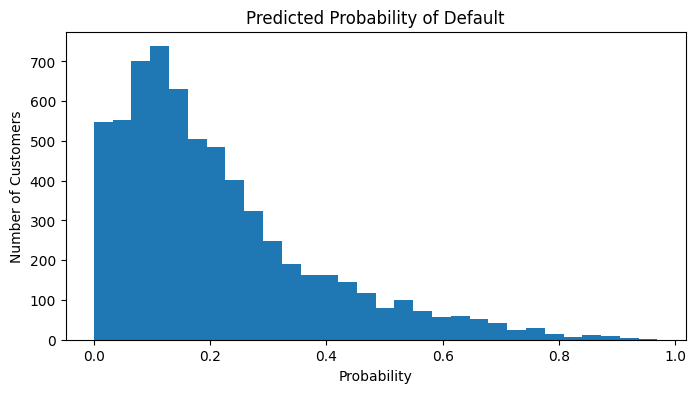

In [107]:
# VISUAL: HISTOGRAM OF PREDICTED PROBABILITIES


plt.figure(figsize=(8, 4))
plt.hist(y_prob, bins=30)

plt.title('Predicted Probability of Default')
plt.xlabel('Probability')
plt.ylabel('Number of Customers')
plt.show()

# STEP 9: MODEL EVALUATION
- Since target is imbalanced, do not rely on accuracy

In [109]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8253

Confusion Matrix:
[[4945  121]
 [1012  406]]


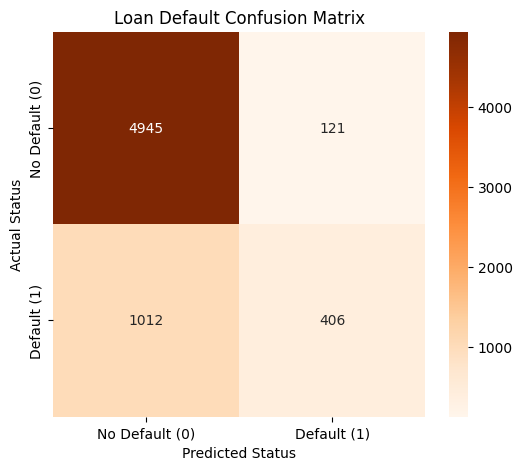

In [111]:
# Plot the Confusion Matrix with absolute counts
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Default (0)', 'Default (1)'], 
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Loan Default Confusion Matrix')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

In [114]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90      5066
           1       0.77      0.29      0.42      1418

    accuracy                           0.83      6484
   macro avg       0.80      0.63      0.66      6484
weighted avg       0.82      0.83      0.79      6484



# Which Metrics to Use?

## Recall (Sensitivity) on Class 1 (Primary Metric):
- What it means: Out of all people who actually defaulted, what percentage did the model catch?
- Why it matters: In lending, False Negatives are catastrophic. If you accidentally give a loan to a borrower who will default, you lose the entire loan principal. You want Recall to be as high as possible.


## Precision on Class 1:
- What it means: When the model flags someone as a default risk, how often is it actually right?
- Why it matters: If Precision is too low, you have too many False Positives. You will end up rejecting good, profitable customers, causing the bank to lose business.

ROC-AUC Score: 0.8001





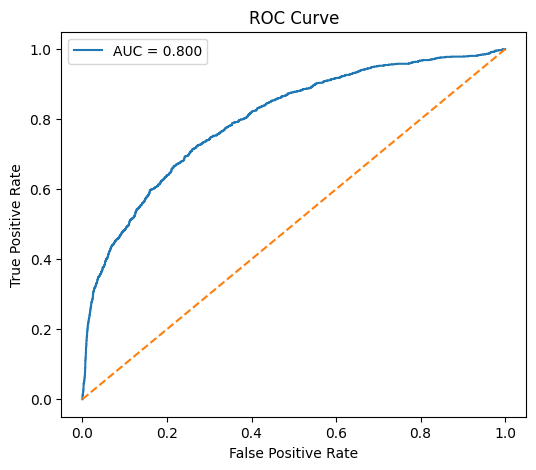

In [113]:
# VISUAL: ROC CURVE

from sklearn.metrics import roc_curve, roc_auc_score


# ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc, 4))
print("\n\n")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## ROC-AUC
```
Measures ranking quality.

Interpretation:

0.50 → random guessing
0.70 → acceptable
0.80 → good
0.90+ → excellent

In [31]:
# INTERPRET A FEW PREDICTIONS

# Create a comparison table
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_of_Default": y_prob
})

results.head(10)

,Actual,Predicted,Probability_of_Default
0,0,0,0.281678
1,0,0,0.186340
2,0,0,0.000450
3,0,0,0.350543
4,0,0,0.375071
5,0,0,0.270642
6,0,0,0.239006
7,0,0,0.158755
8,0,0,0.163937
9,1,1,0.924872


# View the Most Risky Customers

In [33]:
results.sort_values(
    by="Probability_of_Default",
    ascending=False
).head(10)

,Actual,Predicted,Probability_of_Default
5037,1,1,0.977057
4985,1,1,0.971208
5300,1,1,0.966606
3555,1,1,0.956509
5702,0,1,0.943807
6387,1,1,0.942124
110,1,1,0.936188
300,1,1,0.935558
3768,1,1,0.933324
9,1,1,0.924872


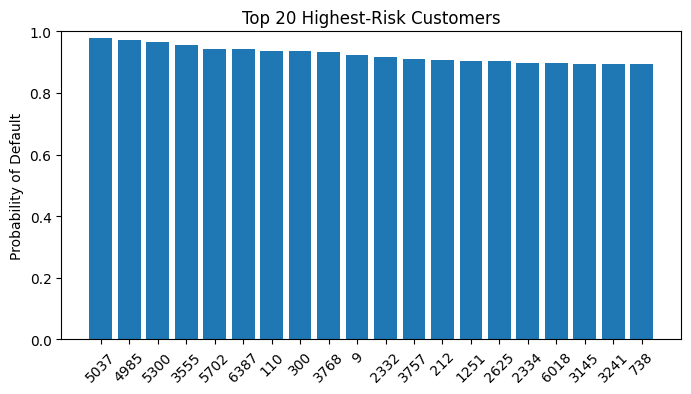

In [49]:
# VISUAL : TOP N HIGHEST RISK CUSTOMERS
N=20

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability_of_Default': y_prob
})

top_N = results.sort_values(
    by='Probability_of_Default',
    ascending=False
).head(N)

plt.figure(figsize=(8, 4))
plt.bar(
    range(len(top_N)),
    top_N['Probability_of_Default']
)

plt.xticks(
    range(len(top_N)),
    top_N.index,
    rotation=45
)

plt.ylim(0, 1)
plt.title(f'Top {N} Highest-Risk Customers')
plt.ylabel('Probability of Default')
plt.show()